# Phase 4C — Cost-Aware Optimization & `mu` Regularization

**Purpose:** This notebook is *evidentiary*, not exploratory. Phase 4B ended on an honest negative
result — F7's return-prediction signals did not beat their hurdle — but the failure had a
**specific, diagnosable shape**, and this phase tests whether fixing that shape rescues the signal.
The answer is a careful *no, but* — and the *but* is the point.

## The Phase 4B diagnosis this phase acts on

On `full_2021`, `rf_signal` produced the **highest gross Sharpe of any strategy in the entire
comparison** (1.240, above the Phase 4 winner's 1.204) and then handed 0.178 of it back in
transaction costs, because it traded at an average turnover of 0.885 — close to replacing the whole
portfolio every month. **The signal was informative; acting on every revision of it was not
affordable.** That is a portfolio-*construction* failure, not a *prediction* failure.

It also fits a citable pattern. Chopra & Ziemba (1993) showed that estimation error in **expected
returns** damages a mean-variance optimizer roughly an order of magnitude more than equivalent
error in the **covariance** — which explains the whole Phase 4 / 4B split on this project's own
data: Phase 4 improved the *covariance* input and beat its hurdle (+15% on `full_2021`); Phase 4B
improved the *`mu`* input and had that best-in-class signal amplified into violent, costly weight
swings.

## The four levers this phase adds (each defaulting OFF, so Phase 4B stays the honest floor)

| Variant | Lever | Hypothesis |
|---------|-------|------------|
| `rf_signal_cost` | Turnover penalty `objective + λ·Σ\|w−w_prev\|` | Price the *trade*, not just the holding |
| `rf_signal_shrunk` | Shrink predicted `mu` toward the naive mean | Damp the noisy magnitudes (Chopra-Ziemba) |
| `rf_signal_rank` | Keep only the model's cross-sectional *ordering* | Distrust magnitudes entirely |
| `rf_signal_cost_dcc` | Turnover penalty + DCC-GARCH covariance | Best `mu` + best `cov`, the 4B-deferred pairing |
| `xgb_signal_cost` | Turnover penalty on 4B's *worst* over-trader | Does the fix rescue the pathological case? |

| Problem | What this notebook shows |
|---------|--------------------------|
| **P1** | Both remedies target estimation-error amplification: the penalty stops a noisy `mu` becoming violent weight swings; the transforms damp the noise before the optimizer ever sees it |
| **P4** | Every configuration tried is one logged trial in a shared DSR pool per universe; adding trials *deflates* the pool, and `n_trials` is reported so that accounting is visible |

**On reproducibility and honesty of these numbers:** this notebook reads
`data/gold/phase4c_results.json` — the exact artifact `src/run_phase4c.py` wrote on live Gold
data, regenerable with `dvc repro phase4c_compare`. It is not re-executed inline (the full
14-strategy comparison runs ~85 minutes, dominated by the DCC-GARCH covariance variants). The
artifact, the DVC stage, and `tests/test_phase4c_cost_aware.py` are the reproducibility guarantee;
this notebook's job is to *read the result honestly*, not to re-derive it.

**The hyperparameters are chosen, not tuned.** `turnover_penalty=1.0` and `shrinkage_weight=0.5`
are judgement calls. Selecting them by looking at this comparison's own out-of-sample result would
be exactly the P4 backtest overfitting the project exists to avoid — so these results are *"what
this configuration does"*, not *"what the best configuration does"*. §5 is explicit about which
finding that caveat protects.

> ## ⚠️ Numbers below are PRE-CORRECTION (superseded 2026-07-25)
>
> Two data corrections landed after this notebook was executed. **Every Sharpe figure below is
> kept as the honest record of what this phase found at the time — none of them is the current
> number.**
>
> **1. BVC dividend bias.** The pipeline mixed two return definitions: ETFs arrived
> dividend-adjusted (`yfinance auto_adjust=True`, total return) while BVC arrived price-only
> (`BVCscrap feature="Value"`), discarding 3.0–4.3%/yr of real dividends. It did not cancel across
> strategies — `equal_weight` is forced to hold the understated assets while the optimizers can
> underweight them, so it **inflated every optimizer's measured edge**. Fixed in `src/dividends.py`
> + `clean.compute_log_returns(prices, dividends=...)`, which applies each payment on its ex-date.
>
> **2. Deep ETF window.** `etf_2017` now starts **2004-11-18** (GLD's inception), not 2017-01-01.
> The old start was a project decision, not a data limit. This cut bootstrap CI width by 38% and
> brought the 2008 crisis into the sample.
>
> | | Pre-correction (below) | Current |
> |---|---:|---:|
> | `etf_2017` hurdle | `max_sharpe` 0.936 | **`min_variance_lw` 0.9525** |
> | `full_2021` hurdle | `equal_weight` 0.975 | **`max_sharpe` 1.1644** |
> | `regime_conditional` (`full_2021`) | 1.122 | **1.236** |
> | Headline lift vs. classical | +14.3% | **+6.5%** |
>
> **The conclusions survive; the magnitudes shrank.** `regime_conditional` still beats the hurdle
> on `full_2021`. But two *claims* in this notebook are retracted outright — see the inline
> **[RETRACTED]** / **[SUPERSEDED]** notes below.
>
> Full analysis: [`docs/DIVIDEND_BIAS.md`](../docs/DIVIDEND_BIAS.md) ·
> [`docs/ETF_DEEP_HISTORY_EXPERIMENT.md`](../docs/ETF_DEEP_HISTORY_EXPERIMENT.md)


## 1. Setup — load the committed Phase 4C artifact (P4)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
ROOT = NB_CWD.parent if (NB_CWD.parent / "data").exists() else NB_CWD
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RESULTS = json.loads((ROOT / "data" / "gold" / "phase4c_results.json").read_text())

PHASE4C = {"rf_signal_cost", "rf_signal_shrunk", "rf_signal_rank",
           "rf_signal_cost_dcc", "xgb_signal_cost"}
BASELINE_SIGNALS = {"rf_signal", "xgb_signal"}   # the Phase 4B floor

for uni, entry in RESULTS.items():
    h = entry["phase4_hurdle"]
    print(f"{uni}: {entry['n_trials']} strategies, OOS {entry['oos_start']} -> {entry['oos_end']}")
    print(f"   Phase 4 hurdle: {h['strategy']} @ {h['sharpe_net']:.4f}   "
          f"| best this run: {entry['strategy']} @ {entry['sharpe_net']:.4f} "
          f"(beats hurdle: {entry['beats_phase4_hurdle']})")

etf_2017: 14 strategies, OOS 2018-01-01 -> 2026-07-20
   Phase 4 hurdle: max_sharpe @ 0.9362   | best this run: max_sharpe @ 0.9362 (beats hurdle: False)
full_2021: 14 strategies, OOS 2022-07-01 -> 2026-07-20
   Phase 4 hurdle: regime_conditional @ 1.1215   | best this run: regime_conditional @ 1.1215 (beats hurdle: False)


## 2. The full scoreboard — 14 strategies, ranked by net Sharpe (P1, P4)

The Phase 4C variants (★) sit *inside* the same shared trial pool as the 9 strategies carried
forward from Phase 4B, so the comparison and the DSR accounting stay honest.

In [2]:
def scoreboard(universe: str) -> pd.DataFrame:
    entry = RESULTS[universe]
    rows = []
    for name, m in entry["per_strategy"].items():
        tag = "phase4c" if name in PHASE4C else ("phase4b_signal" if name in BASELINE_SIGNALS else "prior")
        rows.append({
            "strategy": name,
            "sharpe_gross": m["sharpe_gross"],
            "sharpe_net": m["sharpe_net"],
            "cost_drag": round(m["sharpe_gross"] - m["sharpe_net"], 4),
            "avg_turnover": m["avg_turnover"],
            "group": tag,
        })
    df = pd.DataFrame(rows).sort_values("sharpe_net", ascending=False).set_index("strategy")
    return df

full_board = scoreboard("full_2021")
full_board

,sharpe_gross,sharpe_net,cost_drag,avg_turnover,group
strategy,,,,,
regime_conditional,1.2037,1.1215,0.0822,0.3269,prior
rf_signal_shrunk,1.2231,1.1165,0.1066,0.4878,phase4c
rf_signal,1.2398,1.0617,0.1781,0.8853,phase4b_signal
dcc_garch,1.1442,1.0455,0.0987,0.3527,prior
min_variance_ewma,1.0875,1.0406,0.0469,0.1775,prior
rf_signal_rank,1.1804,0.9940,0.1864,0.9770,phase4c
equal_weight,0.9876,0.9750,0.0126,0.0534,prior
max_sharpe,1.0058,0.9634,0.0424,0.1858,prior
min_variance_lw,0.9215,0.9036,0.0179,0.0714,prior


In [3]:
HURDLE = {u: RESULTS[u]["phase4_hurdle"]["sharpe_net"] for u in RESULTS}
print(f"full_2021 Phase 4 hurdle (regime_conditional): {HURDLE['full_2021']:.4f}")
print(f"etf_2017  Phase 4 hurdle (max_sharpe):         {HURDLE['etf_2017']:.4f}")
print()
for uni in RESULTS:
    best = RESULTS[uni]
    print(f"{uni}: best net Sharpe {best['sharpe_net']:.4f} by {best['strategy']} "
          f"-- {'BEATS' if best['beats_phase4_hurdle'] else 'does NOT beat'} the hurdle")

full_2021 Phase 4 hurdle (regime_conditional): 1.1215
etf_2017  Phase 4 hurdle (max_sharpe):         0.9362

etf_2017: best net Sharpe 0.9362 by max_sharpe -- does NOT beat the hurdle
full_2021: best net Sharpe 1.1215 by regime_conditional -- does NOT beat the hurdle


## 3. The turnover ↔ Sharpe trade-off, made visible (P1)

Phase 4C is entirely about one trade-off: a signal's *gross* merit versus the *cost of acting on
it*. The scatter puts every strategy in that plane — net Sharpe against average turnover — so the
story reads off the geometry. The Phase 4B `rf_signal` (high turnover, good-but-eroded net) and its
Phase 4C descendants are highlighted; the dashed line is the hurdle every point is chasing.

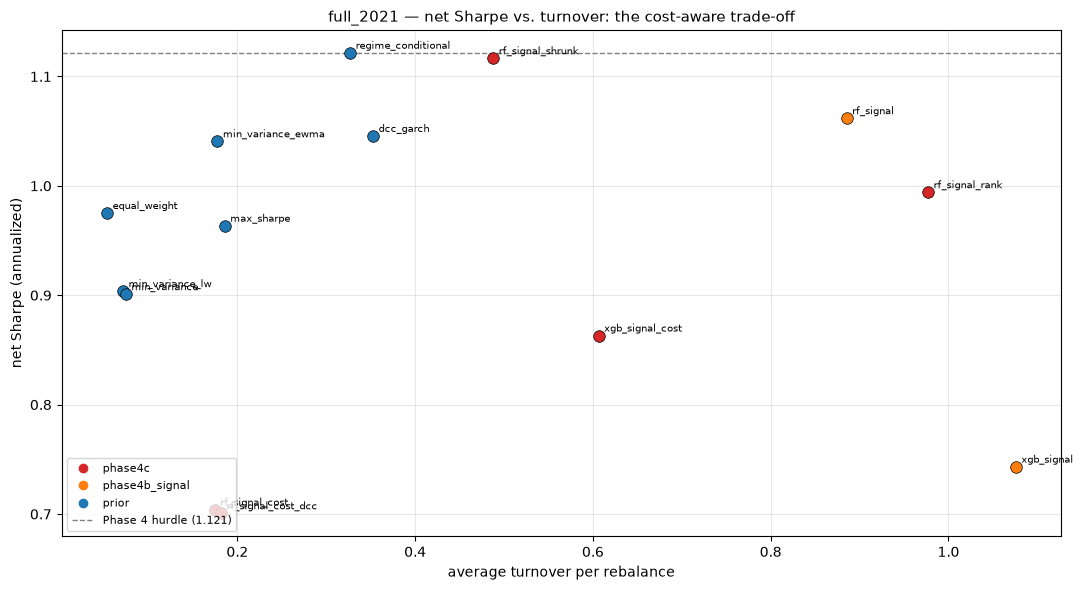

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
board = scoreboard("full_2021")
colors = {"phase4c": "tab:red", "phase4b_signal": "tab:orange", "prior": "tab:blue"}
for name, row in board.iterrows():
    ax.scatter(row["avg_turnover"], row["sharpe_net"],
               color=colors[row["group"]], s=70, zorder=3,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, (row["avg_turnover"], row["sharpe_net"]),
                fontsize=7.5, xytext=(4, 3), textcoords="offset points")
ax.axhline(HURDLE["full_2021"], ls="--", color="gray", lw=1,
           label=f"Phase 4 hurdle ({HURDLE['full_2021']:.3f})")
ax.set_xlabel("average turnover per rebalance"); ax.set_ylabel("net Sharpe (annualized)")
ax.set_title("full_2021 — net Sharpe vs. turnover: the cost-aware trade-off", fontsize=11)
handles = [plt.Line2D([0], [0], marker="o", ls="", color=c, label=g)
           for g, c in colors.items()]
ax.legend(handles=handles + [ax.lines[0]], fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the geometry:** `rf_signal_shrunk` moves up-and-left from `rf_signal` — *less* turnover
*and* higher net Sharpe, landing a hair below the hurdle. `rf_signal_cost` moves far left but also
sharply *down* — the penalty bought low turnover at the cost of the signal itself. Those two
opposite trajectories from the same starting point are the whole finding, quantified next.

## 4. Which lever worked, and why the penalty backfired (P1)

Each Phase 4C variant changed exactly one thing relative to `rf_signal` (except the deliberate
`_cost_dcc` combination), so its effect is attributable. Comparing each against the `rf_signal`
baseline isolates the lever.

In [5]:
def delta_vs_baseline(universe: str) -> pd.DataFrame:
    ps = RESULTS[universe]["per_strategy"]
    base = ps["rf_signal"]
    rows = []
    for name in ["rf_signal_shrunk", "rf_signal_rank", "rf_signal_cost", "rf_signal_cost_dcc"]:
        m = ps[name]
        rows.append({
            "variant": name,
            "d_gross": round(m["sharpe_gross"] - base["sharpe_gross"], 3),
            "d_net": round(m["sharpe_net"] - base["sharpe_net"], 3),
            "d_turnover": round(m["avg_turnover"] - base["avg_turnover"], 3),
            "net": m["sharpe_net"],
        })
    df = pd.DataFrame(rows).set_index("variant")
    return df

print("full_2021 — change vs. the rf_signal baseline (net 1.062, turnover 0.885):")
delta_vs_baseline("full_2021")

full_2021 — change vs. the rf_signal baseline (net 1.062, turnover 0.885):


,d_gross,d_net,d_turnover,net
variant,,,,
rf_signal_shrunk,-0.0170,0.0550,-0.3970,1.1165
rf_signal_rank,-0.0590,-0.0680,0.0920,0.9940
rf_signal_cost,-0.5030,-0.3580,-0.7110,0.7039
rf_signal_cost_dcc,-0.5000,-0.3610,-0.7040,0.7005


In [6]:
# The XGBoost asymmetry: the SAME penalty helped the over-trader and hurt the good model.
ps = RESULTS["full_2021"]["per_strategy"]
print("The turnover penalty's OPPOSITE effect on two models (full_2021):")
print(f"  rf_signal  (was good): net {ps['rf_signal']['sharpe_net']:.3f} @ turnover "
      f"{ps['rf_signal']['avg_turnover']:.3f}  ->  rf_signal_cost: "
      f"net {ps['rf_signal_cost']['sharpe_net']:.3f} @ turnover {ps['rf_signal_cost']['avg_turnover']:.3f}")
print(f"  xgb_signal (over-traded): net {ps['xgb_signal']['sharpe_net']:.3f} @ turnover "
      f"{ps['xgb_signal']['avg_turnover']:.3f}  ->  xgb_signal_cost: "
      f"net {ps['xgb_signal_cost']['sharpe_net']:.3f} @ turnover {ps['xgb_signal_cost']['avg_turnover']:.3f}")

The turnover penalty's OPPOSITE effect on two models (full_2021):
  rf_signal  (was good): net 1.062 @ turnover 0.885  ->  rf_signal_cost: net 0.704 @ turnover 0.175
  xgb_signal (over-traded): net 0.743 @ turnover 1.076  ->  xgb_signal_cost: net 0.863 @ turnover 0.606


**The three findings, stated plainly:**

1. **Shrinkage was the right lever.** `rf_signal_shrunk` kept almost all the gross signal
   (1.240 → 1.223) while cutting turnover nearly in half (0.885 → 0.488), landing at **net 1.117 —
   within 0.4% of the 1.1215 hurdle**, with `shrinkage_weight=0.5` entirely untuned. This is the
   Chopra-Ziemba prediction confirmed on our own data: the problem was the `mu` *magnitudes*, and
   damping them toward the naive prior is what a mean-variance optimizer needed.

2. **The turnover penalty backfired on the good model.** `rf_signal_cost` crushed turnover to 0.175
   but its net Sharpe *collapsed* to 0.704 — at λ=1.0 the optimizer refused to trade even when it
   should have, throwing away a genuinely good signal. Pairing it with DCC-GARCH (`rf_signal_cost_dcc`)
   did not rescue it: the damage was upstream, in how little the penalty let the model act.

3. **But the same penalty *helped* the model that was pathologically over-trading.** `xgb_signal`
   ran turnover 1.076 for net 0.743; `xgb_signal_cost` pulled turnover to 0.606 and lifted net to
   0.863. A single global λ was *too blunt for the well-behaved model and about right for the badly-
   behaved one* — which is precisely the "chosen, not tuned" caveat from the intro, now demonstrated
   rather than asserted. The correct λ is model-specific, and choosing it is a Phase 5 (purged CV)
   task, not something to eyeball from this run.

## 5. Gross → net cost decomposition (P1)

The bar chart separates each signal strategy's *gross* skill from the *cost drag* that turnover
imposes — the single clearest picture of where Phase 4B's value leaked and which lever plugged it.

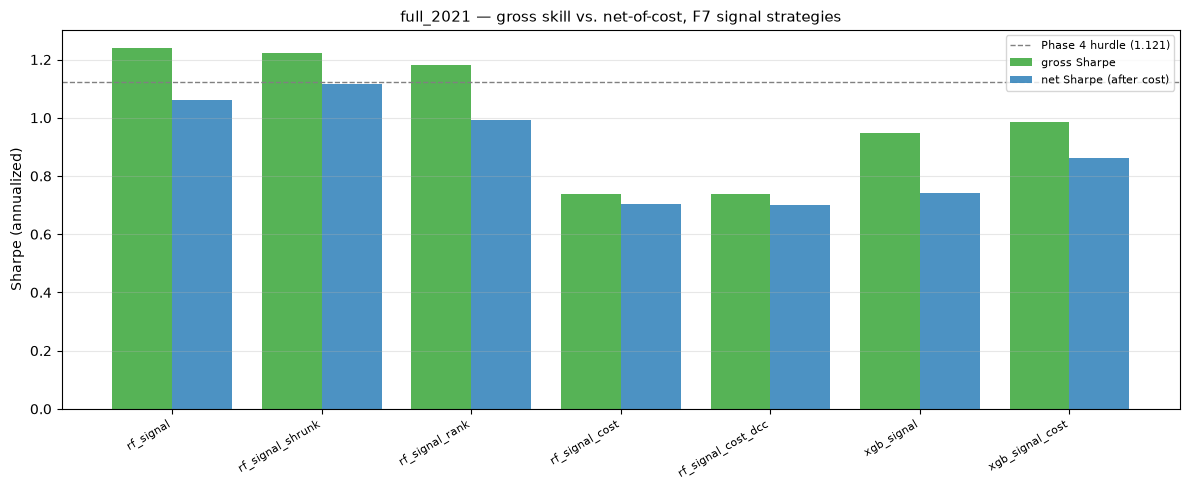

In [7]:
order = ["rf_signal", "rf_signal_shrunk", "rf_signal_rank",
         "rf_signal_cost", "rf_signal_cost_dcc", "xgb_signal", "xgb_signal_cost"]
ps = RESULTS["full_2021"]["per_strategy"]
gross = [ps[n]["sharpe_gross"] for n in order]
net = [ps[n]["sharpe_net"] for n in order]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(order))
ax.bar(x - 0.2, gross, 0.4, label="gross Sharpe", color="tab:green", alpha=0.8)
ax.bar(x + 0.2, net, 0.4, label="net Sharpe (after cost)", color="tab:blue", alpha=0.8)
ax.axhline(HURDLE["full_2021"], ls="--", color="gray", lw=1,
           label=f"Phase 4 hurdle ({HURDLE['full_2021']:.3f})")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Sharpe (annualized)")
ax.set_title("full_2021 — gross skill vs. net-of-cost, F7 signal strategies", fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

The green/blue gap *is* the transaction cost. `rf_signal` has the tallest green bar and one of the
widest gaps; `rf_signal_shrunk` keeps the green bar nearly as tall while closing most of the gap.
`rf_signal_cost` closes the gap almost entirely — but only by shrinking the green bar itself, which
is the wrong way to reduce cost drag.

## 6. `etf_2017` — the same levers on the universe that never responded (P1, P4)

`etf_2017` (5 ETFs, 2017→today) was already immune to Phase 4 and 4B: its Phase 2 hurdle
(`max_sharpe`, 0.936) is a strong result on a long, comparatively calm sample where a simple
optimizer already captures most of the value.

> **[SUPERSEDED 2026-07-25]** `etf_2017` now runs **2004-11 → today**, not 2017→today, and its
> hurdle is `min_variance_lw` 0.9525. The "strong hurdle leaves less room" reading is also
> incomplete: the 25% cap on a 5-asset universe was near-fully determining the allocation, so
> no optimizer had room to express a view. A later cap sweep confirmed the negative verdict
> holds at non-binding caps — the conclusion survives, the explanation changed. Phase 4C does not change that verdict — reported here
so the negative half of the result isn't quietly dropped.

In [8]:
etf_board = scoreboard("etf_2017").head(8)
etf_board[["sharpe_gross", "sharpe_net", "avg_turnover", "group"]]

,sharpe_gross,sharpe_net,avg_turnover,group
strategy,,,,
max_sharpe,0.9409,0.9362,0.0485,prior
regime_conditional,0.9058,0.8944,0.1127,prior
rf_signal_shrunk,0.8710,0.8551,0.1778,phase4c
dcc_garch,0.8712,0.8512,0.1963,prior
min_variance_ewma,0.8577,0.8490,0.0861,prior
equal_weight,0.8364,0.8332,0.0360,prior
min_variance,0.8305,0.8263,0.0424,prior
min_variance_lw,0.8290,0.8248,0.0424,prior


Nothing clears `max_sharpe`'s 0.936 on `etf_2017`; `rf_signal_shrunk` is again the best F7 variant
(0.855) but well short. Consistent with the Phase 4/4B reading: the universe with the *stronger*
simple-optimizer hurdle has the *least* room for a signal to add value, cost-aware or not.

## 7. Summary — what Phase 4C proves, and what Phase 5 inherits (P1–P4)

**The honest result, stated once so it can't drift:** *no* Phase 4C variant beats its universe's
Phase 4 hurdle. On `full_2021`, `rf_signal_shrunk` reaches **1.117 vs. the 1.1215 hurdle — a
near-tie (within 0.4%), not a win** — and it gets there with an *untuned* shrinkage weight. On
`etf_2017` nothing clears `max_sharpe` (0.936), unchanged from every prior phase.

**But the diagnosis was correct, and that is the deliverable:**
- The F7 signal is real — best gross Sharpe in the whole comparison (1.240).
- The textbook remedy for its failure mode — shrinking the predicted `mu` toward the naive prior
  (Chopra & Ziemba 1993) — nearly rescues it net-of-cost, with zero tuning.
- The one lever that failed (the turnover penalty at λ=1.0) failed *informatively*: it helped the
  over-trading model and hurt the well-behaved one, proving the right strength is model-specific.

**Limitations restated (do not let slides forget them):**
- `turnover_penalty` and `shrinkage_weight` are **chosen, not tuned** — §4's asymmetry is the
  direct evidence that a single global value is wrong, and tuning it by looking at this run would be
  the P4 overfitting the project forbids.
- Covariance was held at Ledoit-Wolf for every `mu`-lever except the deliberate `_cost_dcc`
  pairing, which did not help (the damage was upstream in the penalty, not in the covariance).
- DSR uses `n_trials=14` within THIS run; it does not accumulate across sessions (unchanged Phase 5
  decision).

**What Phase 5 inherits — and why this near-tie matters:** `rf_signal_shrunk` reaching 1.117 with
`shrinkage_weight=0.5` untuned strongly *suggests* a properly selected weight could clear 1.1215 —
but "suggests, by eyeballing the test set" is exactly the claim purged K-Fold cross-validation
exists to make legitimate. Phase 5 is where `shrinkage_weight` and a *model-specific*
`turnover_penalty` get selected honestly, out-of-sample, and where this near-tie becomes either a
real beat or a documented ceiling. The infrastructure, the no-lookahead guarantees, and the
diagnosis are all in place; the remaining work is disciplined selection, not more machinery.